In [34]:
%pip install langsmith 

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 26.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [35]:
import os 
import dotenv 
from dotenv import load_dotenv

load_dotenv()

os.environ["LANGSMITH_API_KEY"] = os.getenv("LANGSMITH_API_KEY")
os.environ["GEMINI_API_KEY"] = os.getenv("GEMINI_API_KEY")

api_kkeyy = os.getenv("GEMINI_API_KEY")


In [58]:
##create the data points 

from langsmith import Client 
client = Client()
##define the dataset - these are the test data

dataset_name ="Siddhant"
dataset= client.create_dataset(dataset_name)
client.create_examples(
    dataset_id= dataset.id,
    examples= [
  {
    "inputs": {
      "question": "What is LangChain?"
    },
    "outputs": {
      "answer": "A framework for building applications powered by large language models."
    }
  },
  {
    "inputs": {
      "question": "What is LangSmith?"
    },
    "outputs": {
      "answer": "A platform for debugging, monitoring, and evaluating LLM applications."
    }
  },
 
  {
    "inputs": {
      "question": "What is an AI agent?"
    },
    "outputs": {
      "answer": "A system that can reason, plan, and use tools to accomplish tasks autonomously."
    }
  }
 
]

    
)




{'example_ids': ['dff60a75-662d-4d31-8221-21e9b5042673',
  '1d2a356a-c5ee-488d-ba44-178d335c22a9',
  '3574d600-9fc2-40d9-87e1-48f072f5b487'],
 'count': 3,
 'as_of': '2026-06-25T16:48:52.64088879Z'}

In [62]:
from google import genai
from google.genai import types
from langsmith import wrappers

gemini_wala_client = wrappers.wrap_gemini(
    genai.Client(api_key=api_kkeyy)
)

eval_instruction = (
    "You are an expert professor specialized in grading students' answers. "
    "Compare the predicted answer with the reference answer. "
    "Reply with exactly one word: CORRECT or INCORRECT."
)


def correctness(inputs: dict, outputs: dict, reference_outputs: dict) -> bool:
    user_content = f"""
Question:
{inputs['question']}

Reference Answer:
{reference_outputs['answer']}

Predicted Answer:
{outputs['response']}

Respond with exactly one word:
CORRECT
or
INCORRECT
"""

    response = gemini_wala_client.models.generate_content(
        model="gemini-2.5-flash",
        contents=user_content,
        config=types.GenerateContentConfig(
            system_instruction=eval_instruction,
            temperature=0.0,
        ),
    )

    return response.text.strip().upper() == "CORRECT"


def concision(outputs: dict, reference_outputs: dict) -> bool:
    return len(outputs["response"]) < 2 * len(reference_outputs["answer"])

In [63]:
from google.genai import types

default_instructions = (
    "Respond to the user's question in a short, concise manner "
    "(one short sentence)."
)

def my_app(
    question: str,
    model: str = "gemini-2.5-flash",
    instructions: str = default_instructions,
) -> str:

    response = gemini_wala_client.models.generate_content(
        model=model,
        contents=question,
        config=types.GenerateContentConfig(
            system_instruction=instructions,
            temperature=0.2,
        ),
    )

    return response.text

In [64]:
def ls_target(inputs: dict):
    return {
        "response": my_app(inputs["question"])
    }

In [65]:
experiment_results = client.evaluate(
    ls_target,
    data=dataset_name,
    evaluators=[correctness, concision],
    experiment_prefix="gemini-2.5-flash",
    max_concurrency=1,
)

View the evaluation results for experiment: 'gemini-2.5-flash-d05fc8e3' at:
https://smith.langchain.com/o/b45bc901-a355-43b5-93a2-3be0ce0f3130/datasets/0ee9f815-d574-47cd-b1b4-c2cbe98a9540/compare?selectedSessions=edb24c84-c079-4780-966a-db91485b857d




0it [00:00, ?it/s]Error running target function: 429 RESOURCE_EXHAUSTED. {'error': {'code': 429, 'message': 'You exceeded your current quota, please check your plan and billing details. For more information on this error, head to: https://ai.google.dev/gemini-api/docs/rate-limits. To monitor your current usage, head to: https://ai.dev/rate-limit. \n* Quota exceeded for metric: generativelanguage.googleapis.com/generate_content_free_tier_requests, limit: 20, model: gemini-2.5-flash\nPlease retry in 11.445826418s.', 'status': 'RESOURCE_EXHAUSTED', 'details': [{'@type': 'type.googleapis.com/google.rpc.Help', 'links': [{'description': 'Learn more about Gemini API quotas', 'url': 'https://ai.google.dev/gemini-api/docs/rate-limits'}]}, {'@type': 'type.googleapis.com/google.rpc.QuotaFailure', 'violations': [{'quotaMetric': 'generativelanguage.googleapis.com/generate_content_free_tier_requests', 'quotaId': 'GenerateRequestsPerDayPerProjectPerModel-FreeTier', 'quotaDimensions': {'location': 'gl

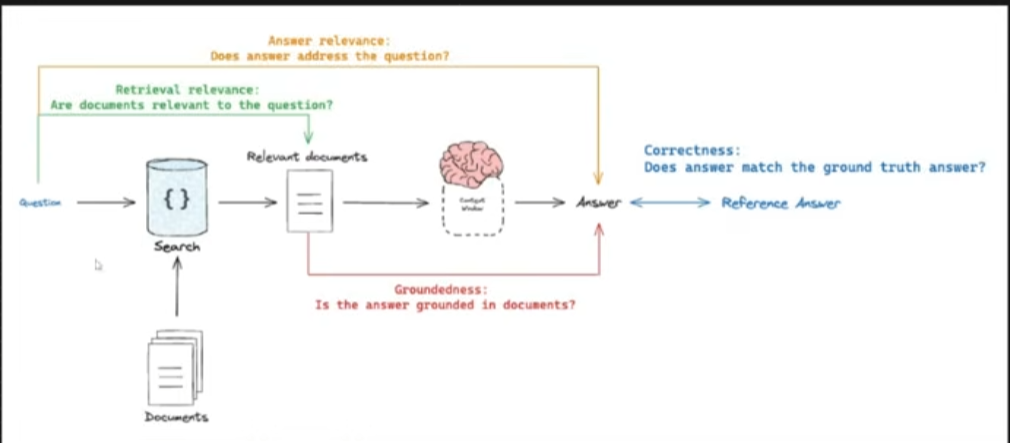